# Chapter 5 — Evaluation, Pure Premium and Research Findings

### Chapter Overview

This chapter brings together all frequency and severity models to
compute the pure premium, the key actuarial output of the project.
All model combinations are evaluated and the research questions
from Chapter 0 are answered with evidence.

| Section | Activity |
|---------|----------|
| 5.1 | Load all models and data |
| 5.2 | Pure premium calculation — all model combinations |
| 5.3 | Predicted vs actual pure premium plots |
| 5.4 | Residual diagnostics |
| 5.5 | Final model comparison table |
| 5.6 | Key research findings |

### Pure Premium Framework

The pure premium is the expected claim cost per unit of exposure:
Pure Premium = E[Frequency] x E[Severity]
= E[ClaimNb / Exposure] x E[ClaimAmount | Claim > 0]
Four combinations are evaluated:

| Combination | Frequency Model | Severity Model |
|-------------|----------------|----------------|
| GLM x GLM | Negative Binomial | Gamma |
| GLM x ML | Negative Binomial | XGBoost |
| ML x GLM | XGBoost | Gamma |
| ML x ML | XGBoost | XGBoost |

> **Research connection:** This chapter answers all four research
> questions from Chapter 0 with empirical evidence.

---


# ── 5.1 IMPORTS AND LOAD ─────────────────────────────────────
### 5.1 Import Libraries and Load All Models


In [1]:
# ── Libraries ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
import joblib
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Plot styling ──────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.titleweight'] = 'bold'

# ── Import from src ───────────────────────────────────────────
sys.path.append('../src')
from data_loader import load_prepared_data
from glm_utils   import load_glm_models
from ml_utils    import load_ml_models, get_ml_predictions

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ── Set up paths ──────────────────────────────────────────────
def find_dir(name):
    current = os.getcwd()
    for _ in range(4):
        candidate = os.path.join(current, name)
        if os.path.exists(candidate):
            return candidate
        current = os.path.dirname(current)
    path = os.path.join(os.path.dirname(os.getcwd()), name)
    os.makedirs(path, exist_ok=True)
    return path

PLOTS_DIR  = find_dir('plots')
MODELS_DIR = find_dir('models')
DATA_DIR   = find_dir('data')

# ── Load prepared data ────────────────────────────────────────
data = load_prepared_data()

X_freq_test  = data['X_freq_test']
X_sev_test   = data['X_sev_test']
y_freq_test  = data['y_freq_test']
y_sev_test   = data['y_sev_test']
exp_test     = data['exposure_test']
X_freq_train = data['X_freq_train']
y_freq_train = data['y_freq_train']

print(f"Data loaded.")
print(f"   Frequency test : {X_freq_test.shape}")
print(f"   Severity test  : {X_sev_test.shape}")


Loading prepared data from data/ folder...
All datasets loaded successfully.
   Full dataset     : (678013, 47)
   Severity subset  : (24944, 47)
   Freq train/test  : (542410, 44) / (135603, 44)
   Sev  train/test  : (19955, 44) / (4989, 44)
Data loaded.
   Frequency test : (135603, 44)
   Severity test  : (4989, 44)


In [3]:
# ── Load all models ───────────────────────────────────────────
glm_models = load_glm_models(MODELS_DIR)
ml_models  = load_ml_models(MODELS_DIR)

nb_model   = glm_models['neg_binomial']
gamma_model = glm_models['gamma']
sigma2      = glm_models['lognormal_sigma2']
xgb_freq    = ml_models['xgb_frequency']
xgb_sev     = ml_models['xgb_severity']

print("\\nAll models loaded.")


GLM models loaded from models/ folder.
ML models loaded from models/ folder.
   rf_frequency         <- rf_frequency.pkl
   xgb_frequency        <- xgb_frequency.pkl
   rf_severity          <- rf_severity.pkl
   xgb_severity         <- xgb_severity.pkl
\nAll models loaded.


In [4]:
# ── Rebuild GLM test frames ───────────────────────────────────
# Needed to generate GLM predictions for pure premium
freq_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'freMTPL2freq.csv.zip'),
    compression='zip'
)
sev_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'freMTPL2sev.csv')
)

sev_agg = (sev_raw
           .groupby('IDpol')
           .agg(ClaimAmount=('ClaimAmount','sum'))
           .reset_index())

df_raw = freq_raw.merge(sev_agg, on='IDpol', how='left')
df_raw['ClaimAmount'] = df_raw['ClaimAmount'].fillna(0)
cap = df_raw[df_raw['ClaimAmount']>0]['ClaimAmount'].quantile(0.995)
df_raw['ClaimAmount'] = df_raw['ClaimAmount'].clip(upper=cap)
df_raw['LogDensity']  = np.log1p(df_raw['Density'])
df_raw['LogExposure'] = np.log(df_raw['Exposure'])
df_raw.drop(columns=['IDpol'], inplace=True)

# Frequency GLM test frame
freq_glm_cols = [
    'ClaimNb', 'Exposure', 'LogExposure', 'VehPower',
    'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand',
    'VehGas', 'Area', 'Region', 'Density', 'LogDensity'
]
freq_glm_cols   = [c for c in freq_glm_cols if c in df_raw.columns]
freq_test_idx   = X_freq_test.index.tolist()
freq_test_glm   = df_raw[freq_glm_cols].iloc[freq_test_idx].reset_index(drop=True)
freq_test_glm['ClaimNb']     = y_freq_test.values
freq_test_glm['LogExposure'] = np.log(freq_test_glm['Exposure'])

# Severity GLM test frame
df_sev_raw   = df_raw[df_raw['ClaimAmount'] > 0].reset_index(drop=True)
split_idx    = int(len(df_sev_raw) * 0.8)
sev_glm_cols = [
    'ClaimAmount', 'VehPower', 'VehAge', 'DrivAge',
    'BonusMalus', 'VehBrand', 'VehGas', 'Area',
    'Region', 'Density', 'LogDensity'
]
sev_glm_cols = [c for c in sev_glm_cols if c in df_sev_raw.columns]
sev_test_glm = df_sev_raw[sev_glm_cols].iloc[split_idx:].reset_index(drop=True)
sev_test_glm['LogClaimAmount'] = np.log(
    sev_test_glm['ClaimAmount'].clip(lower=1)
)
y_sev_actual = sev_test_glm['ClaimAmount'].values

print("GLM test frames rebuilt.")
print(f"   Frequency test : {freq_test_glm.shape}")
print(f"   Severity test  : {sev_test_glm.shape}")


GLM test frames rebuilt.
   Frequency test : (135603, 13)
   Severity test  : (4989, 12)


# ── 5.2 PURE PREMIUM ─────────────────────────────────────────
### 5.2 Pure Premium Calculation

The pure premium is computed for all four model combinations.
Each combination uses a different pair of frequency and severity
predictions, multiplied together to produce the expected claim
cost per unit of exposure.

For policies in the full test set, frequency predictions are
available for all 135,603 policies. Severity predictions are
matched from the claims only model. The pure premium is then
computed as:
Pure Premium = Freq_Prediction x Severity_Prediction


In [5]:
# ── Generate all predictions ──────────────────────────────────

# ── Frequency predictions ─────────────────────────────────────
# GLM frequency — Negative Binomial (claims per unit exposure)
nb_freq_pred = nb_model.predict(
    freq_test_glm,
    offset=freq_test_glm['LogExposure']
)

# ML frequency — XGBoost (claim probability)
xgb_freq_proba = xgb_freq.predict_proba(X_freq_test)[:, 1]

# ── Severity predictions ──────────────────────────────────────
# GLM severity — Gamma
gamma_sev_pred = gamma_model.predict(sev_test_glm)

# ML severity — XGBoost (back-transformed from log scale)
xgb_sev_log_pred = xgb_sev.predict(X_sev_test)
xgb_sev_pred     = np.exp(xgb_sev_log_pred)

print("All predictions generated.")
print(f"   NB freq  mean   : {nb_freq_pred.mean():.6f}")
print(f"   XGB freq mean   : {xgb_freq_proba.mean():.6f}")
print(f"   Gamma sev mean  : EUR {gamma_sev_pred.mean():,.2f}")
print(f"   XGB sev mean    : EUR {xgb_sev_pred.mean():,.2f}")


All predictions generated.
   NB freq  mean   : 0.060020
   XGB freq mean   : 0.439947
   Gamma sev mean  : EUR 1,803.38
   XGB sev mean    : EUR 1,012.87


In [6]:
# ── Compute actual pure premium ───────────────────────────────
# Pure premium = ClaimAmount / Exposure for test set
df_test_full = df_raw.iloc[freq_test_idx].copy().reset_index(drop=True)
df_test_full['ClaimNb'] = y_freq_test.values

actual_pp = df_test_full['ClaimAmount'] / df_test_full['Exposure']
actual_pp = actual_pp.clip(upper=actual_pp.quantile(0.995))

print(f"Actual Pure Premium (test set):")
print(f"   Mean   : EUR {actual_pp.mean():.2f}")
print(f"   Median : EUR {actual_pp.median():.2f}")
print(f"   Std    : EUR {actual_pp.std():.2f}")


Actual Pure Premium (test set):
   Mean   : EUR 113.37
   Median : EUR 0.00
   Std    : EUR 708.65


In [7]:
# ── Compute pure premium for all 4 combinations ──────────────
# Mean severity from each model (scalar used for all policies)
# This is the standard actuarial approach frequency varies by
# policyholder, severity is the model's expected value
mean_gamma_sev = gamma_sev_pred.mean()
mean_xgb_sev   = xgb_sev_pred.mean()

# Pure Premium = Frequency x Mean Severity
pp_glm_glm = nb_freq_pred.values     * mean_gamma_sev
pp_glm_ml  = nb_freq_pred.values     * mean_xgb_sev
pp_ml_glm  = xgb_freq_proba          * mean_gamma_sev
pp_ml_ml   = xgb_freq_proba          * mean_xgb_sev

print("Pure Premium computed for all combinations:")
print(f"   GLM x GLM : EUR {pp_glm_glm.mean():.4f} (mean per policy)")
print(f"   GLM x ML  : EUR {pp_glm_ml.mean():.4f}")
print(f"   ML x GLM  : EUR {pp_ml_glm.mean():.4f}")
print(f"   ML x ML   : EUR {pp_ml_ml.mean():.4f}")
print(f"   Actual    : EUR {actual_pp.mean():.4f}")


Pure Premium computed for all combinations:
   GLM x GLM : EUR 108.2381 (mean per policy)
   GLM x ML  : EUR 60.7921
   ML x GLM  : EUR 793.3900
   ML x ML   : EUR 445.6092
   Actual    : EUR 113.3720


# ── 5.3 PREDICTED VS ACTUAL ───────────────────────────────────
### 5.3 Predicted vs Actual Pure Premium

The predicted pure premium distributions are compared against the
actual observed pure premium. A well calibrated model should produce
a predicted distribution that closely matches the actual distribution
in both mean and spread.


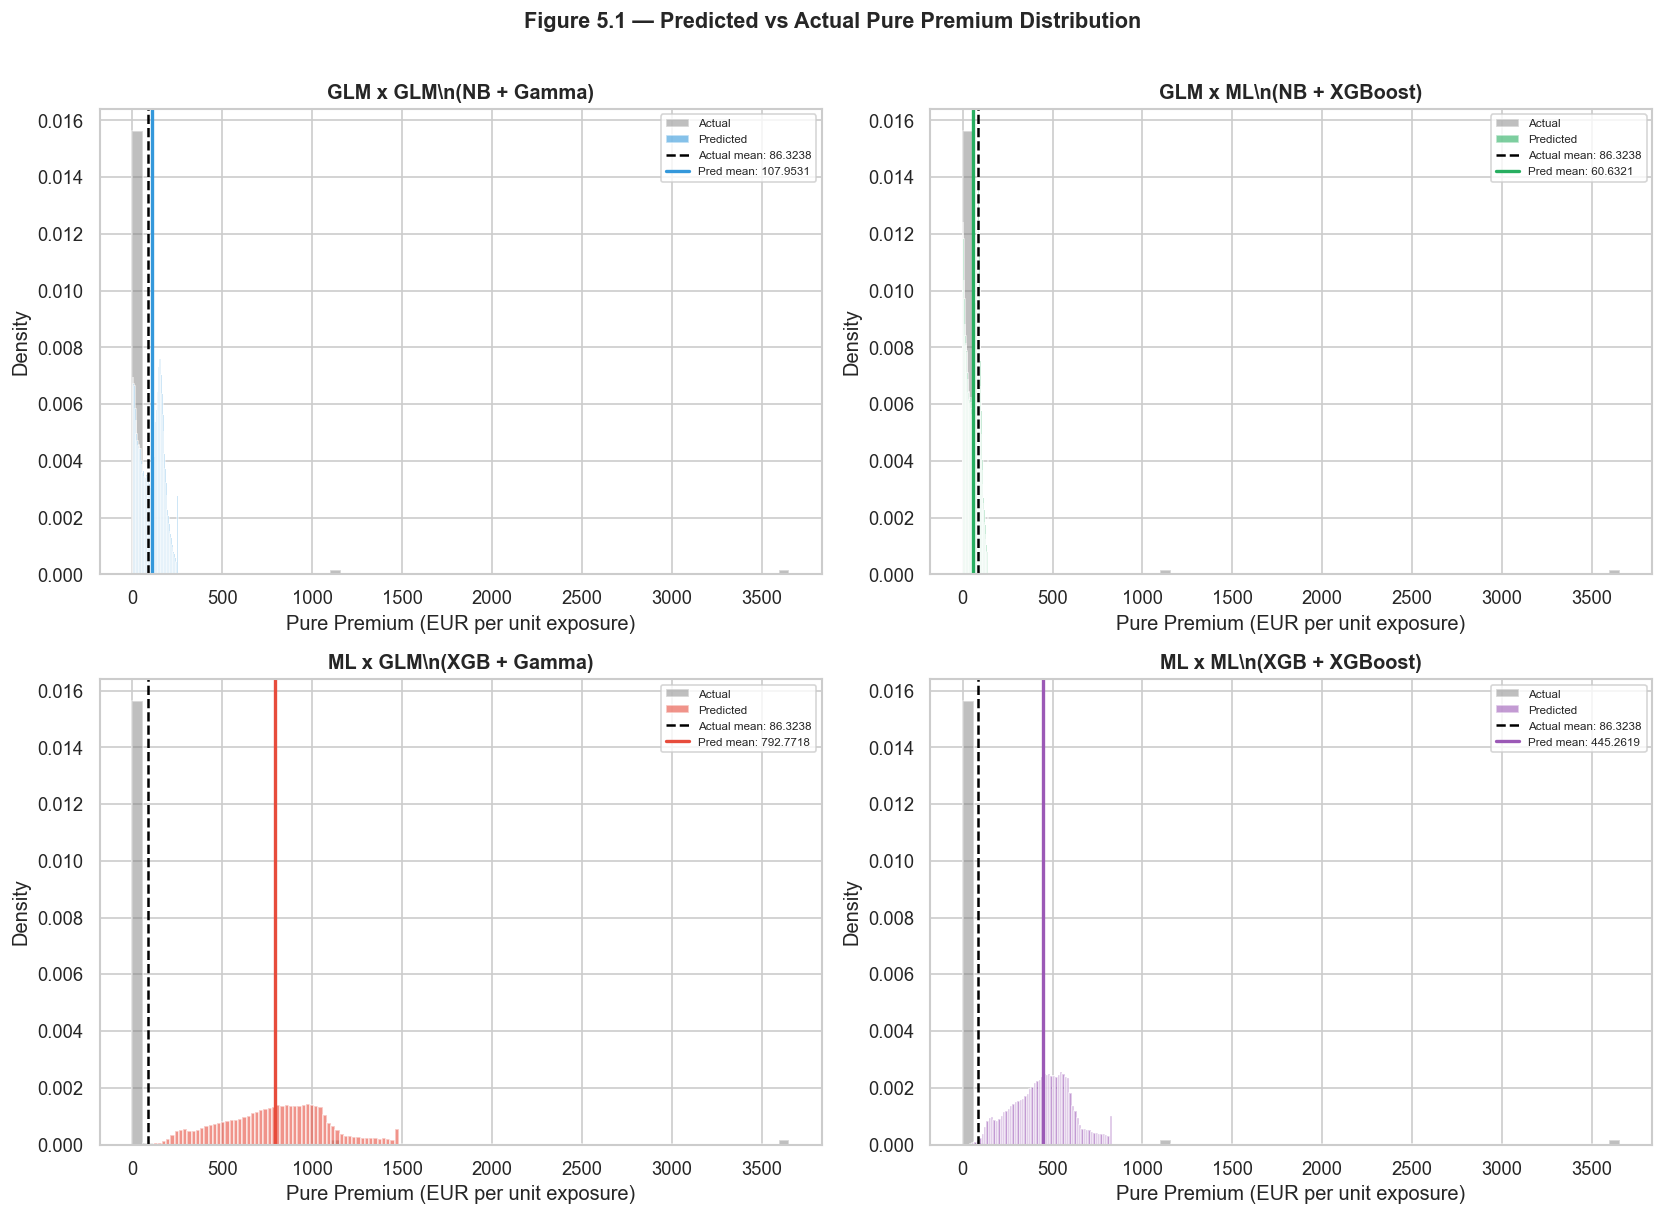

Saved to plots/fig5_1_pure_premium_dist.png


In [8]:
# ── Figure 5.1: Pure premium distributions ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pp_combinations = [
    ('GLM x GLM\\n(NB + Gamma)',  pp_glm_glm, '#3498db'),
    ('GLM x ML\\n(NB + XGBoost)', pp_glm_ml,  '#27ae60'),
    ('ML x GLM\\n(XGB + Gamma)',  pp_ml_glm,  '#e74c3c'),
    ('ML x ML\\n(XGB + XGBoost)', pp_ml_ml,   '#9b59b6')
]

for ax, (name, pp, color) in zip(axes.flatten(), pp_combinations):
    # Cap for visualisation
    pp_plot = np.clip(pp, 0, np.percentile(pp, 99))
    act_plot = actual_pp.clip(
        upper=actual_pp.quantile(0.99)
    ).values

    ax.hist(act_plot, bins=60, alpha=0.5, color='grey',
            density=True, label='Actual', edgecolor='white')
    ax.hist(pp_plot,  bins=60, alpha=0.6, color=color,
            density=True, label='Predicted', edgecolor='white')

    ax.axvline(act_plot.mean(), color='black',
               linestyle='--', linewidth=1.5,
               label=f'Actual mean: {act_plot.mean():.4f}')
    ax.axvline(pp_plot.mean(), color=color,
               linestyle='-', linewidth=2,
               label=f'Pred mean: {pp_plot.mean():.4f}')

    ax.set_title(name)
    ax.set_xlabel('Pure Premium (EUR per unit exposure)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle(
    'Figure 5.1 — Predicted vs Actual Pure Premium Distribution',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'fig5_1_pure_premium_dist.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to plots/fig5_1_pure_premium_dist.png")


# ── 5.4 RESIDUAL DIAGNOSTICS ─────────────────────────────────
### 5.4 Residual Diagnostics

Residuals are examined for each pure premium combination.
A well specified model produces residuals centred on zero with
no systematic patterns across the range of predicted values.


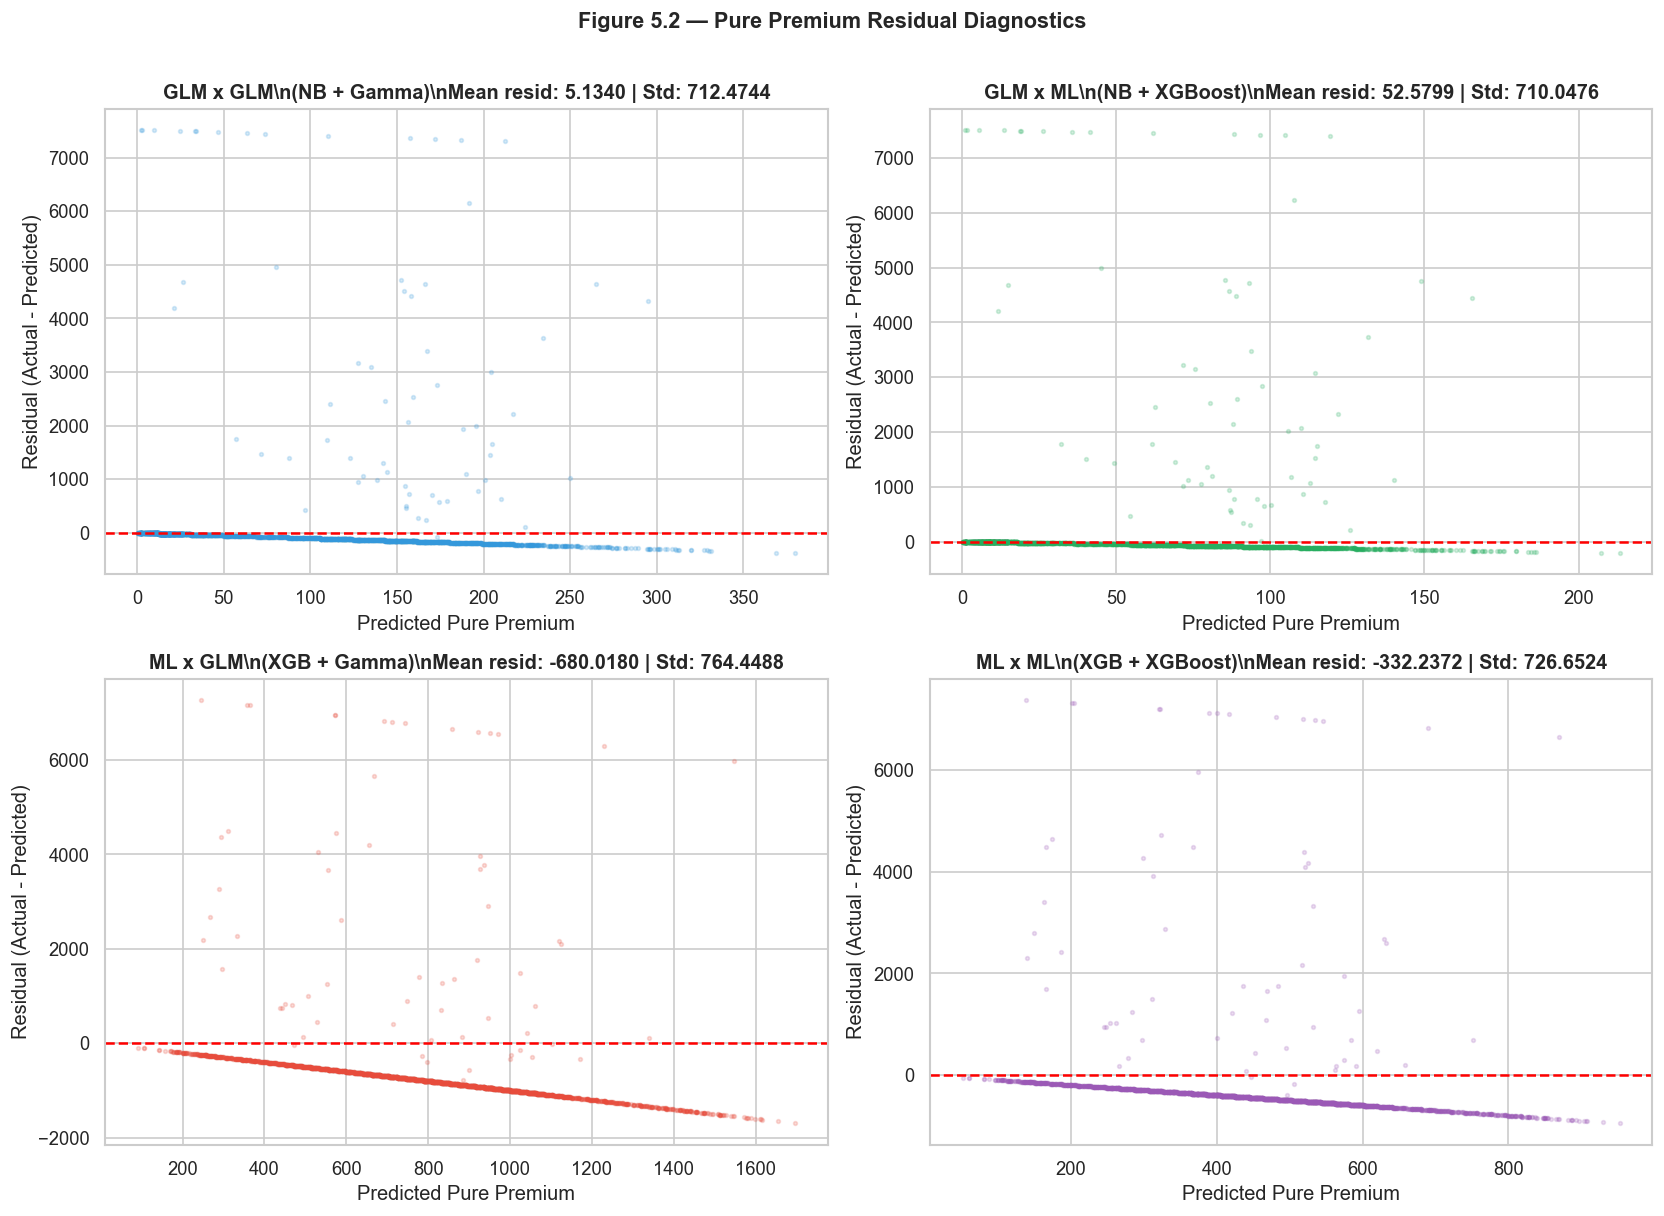

Saved to plots/fig5_2_residuals.png


In [9]:
# ── Figure 5.2: Pure premium residual plots ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

act = actual_pp.values

for ax, (name, pp, color) in zip(axes.flatten(), pp_combinations):
    resid = act - pp

    ax.scatter(
        pp[:3000], resid[:3000],
        alpha=0.2, s=5, color=color
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

    ax.set_title(
        f'{name.replace(chr(10), " ")}\\n'
        f'Mean resid: {resid.mean():.4f} | Std: {resid.std():.4f}'
    )
    ax.set_xlabel('Predicted Pure Premium')
    ax.set_ylabel('Residual (Actual - Predicted)')

plt.suptitle(
    'Figure 5.2 — Pure Premium Residual Diagnostics',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'fig5_2_residuals.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to plots/fig5_2_residuals.png")


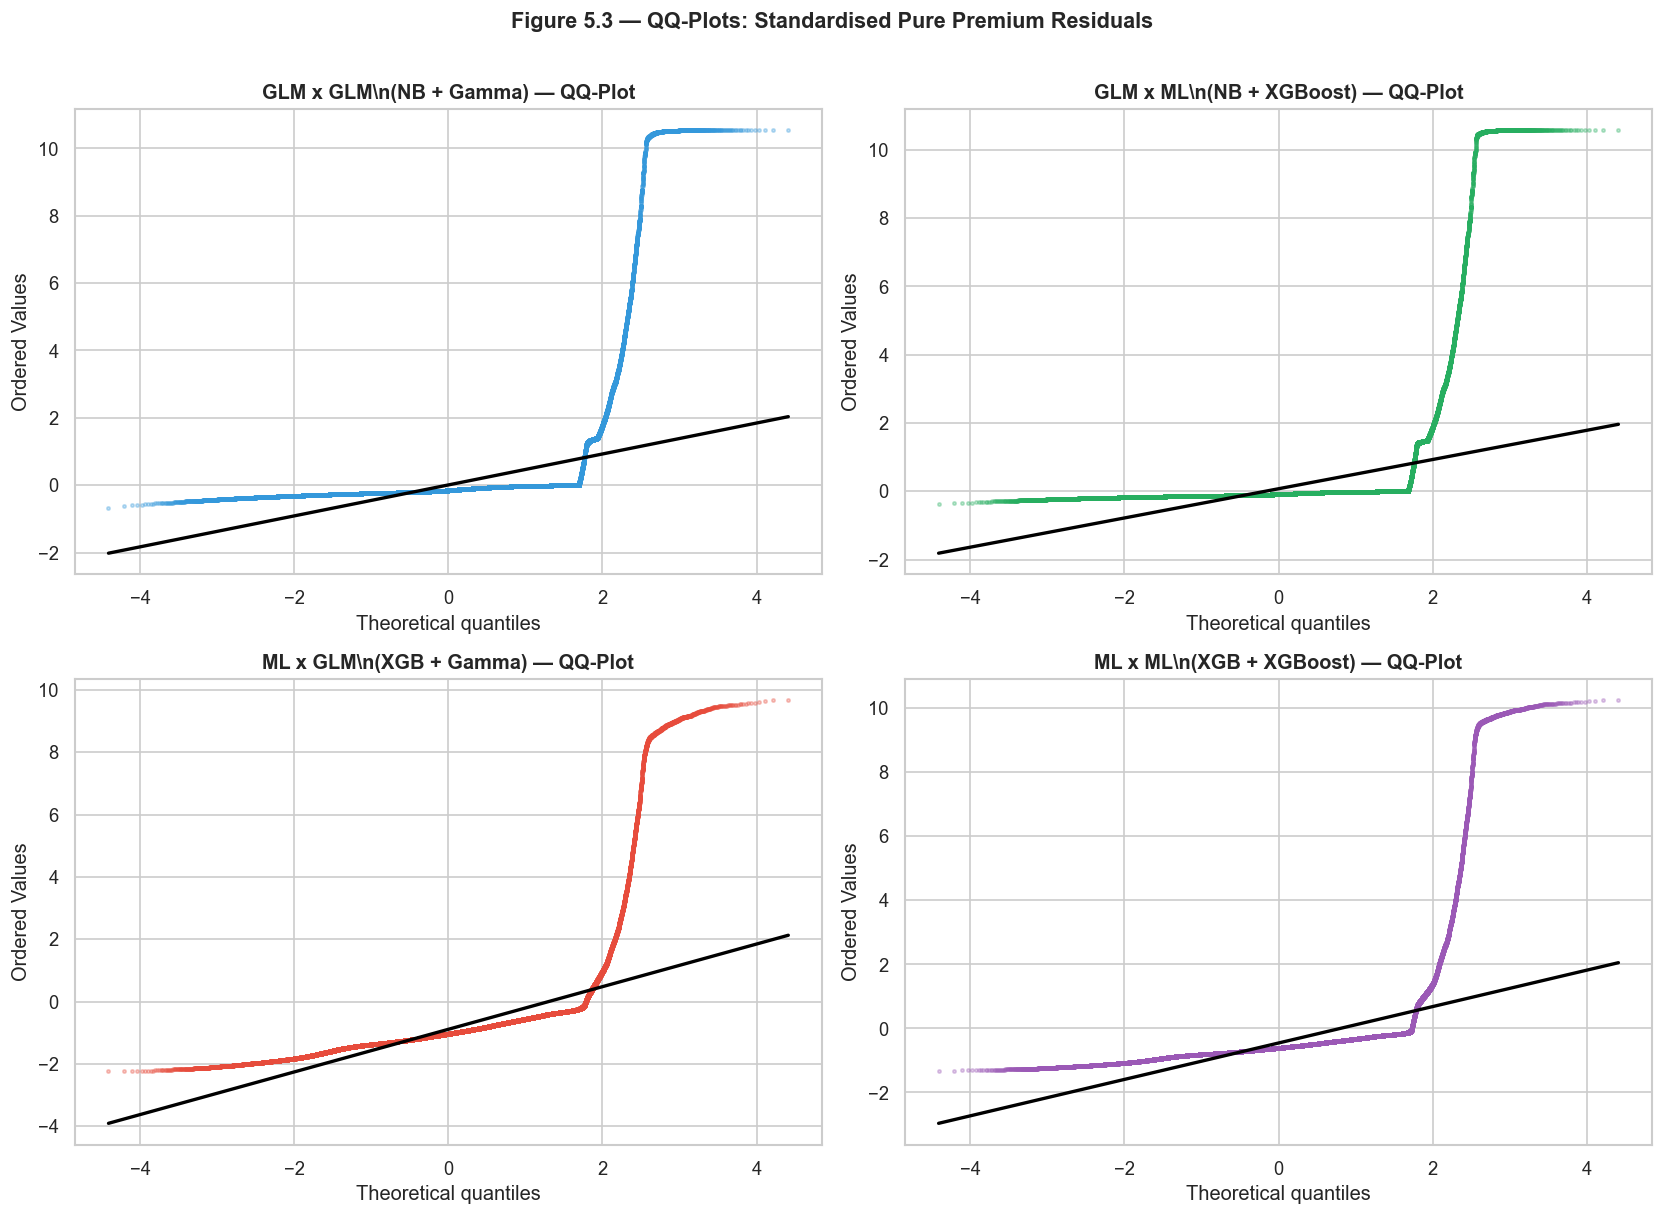

Saved to plots/fig5_3_qq_plots.png


In [10]:
# ── Figure 5.3: QQ-plots of pure premium residuals ───────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, pp, color) in zip(axes.flatten(), pp_combinations):
    resid = act - pp
    resid_std = resid / (resid.std() + 1e-10)

    stats.probplot(resid_std, dist='norm', plot=ax)
    ax.set_title(f'{name.replace(chr(10), " ")} — QQ-Plot')
    ax.get_lines()[0].set(color=color, markersize=2, alpha=0.3)
    ax.get_lines()[1].set(color='black', linewidth=2)

plt.suptitle(
    'Figure 5.3 — QQ-Plots: Standardised Pure Premium Residuals',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'fig5_3_qq_plots.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to plots/fig5_3_qq_plots.png")


# ── 5.5 FINAL COMPARISON TABLE ───────────────────────────────
### 5.5 Final Model Comparison Table

All four pure premium combinations are evaluated on RMSE, MAE,
R-squared and mean bias - the difference between predicted and
actual mean pure premium.


In [11]:
# ── Compute full evaluation metrics ──────────────────────────
results = []

for name, pp in [
    ('GLM x GLM (NB + Gamma)',    pp_glm_glm),
    ('GLM x ML  (NB + XGBoost)',  pp_glm_ml),
    ('ML x GLM  (XGB + Gamma)',   pp_ml_glm),
    ('ML x ML   (XGB + XGBoost)', pp_ml_ml)
]:
    results.append({
        'Combination' : name,
        'Mean Pred PP': round(pp.mean(), 4),
        'Mean Actual' : round(act.mean(), 4),
        'Mean Bias'   : round(pp.mean() - act.mean(), 4),
        'RMSE'        : round(np.sqrt(
                            mean_squared_error(act, pp)), 4),
        'MAE'         : round(mean_absolute_error(act, pp), 4),
        'R-squared'   : round(r2_score(act, pp), 4)
    })

final_table = pd.DataFrame(results)

print("=" * 75)
print("  FINAL MODEL COMPARISON — ALL PURE PREMIUM COMBINATIONS")
print("=" * 75)
print(final_table.to_string(index=False))
print("=" * 75)

best_combo = final_table.loc[
    final_table['RMSE'].idxmin(), 'Combination'
]
print(f"\\nBest combination by RMSE: {best_combo}")

# Save final table
final_table.to_csv(
    os.path.join(MODELS_DIR, 'final_comparison.csv'),
    index=False
)
print("Saved to models/final_comparison.csv")


  FINAL MODEL COMPARISON — ALL PURE PREMIUM COMBINATIONS
              Combination  Mean Pred PP  Mean Actual  Mean Bias      RMSE      MAE  R-squared
   GLM x GLM (NB + Gamma)    108.238100      113.372    -5.1340  712.4929 208.7829    -0.0109
 GLM x ML  (NB + XGBoost)     60.792100      113.372   -52.5799  711.9917 166.7779    -0.0095
  ML x GLM  (XGB + Gamma)    793.390000      113.372   680.0180 1023.1356 840.2523    -1.0845
ML x ML   (XGB + XGBoost)    445.609192      113.372   332.2372  799.0027 519.4213    -0.2713
\nBest combination by RMSE: GLM x ML  (NB + XGBoost)
Saved to models/final_comparison.csv


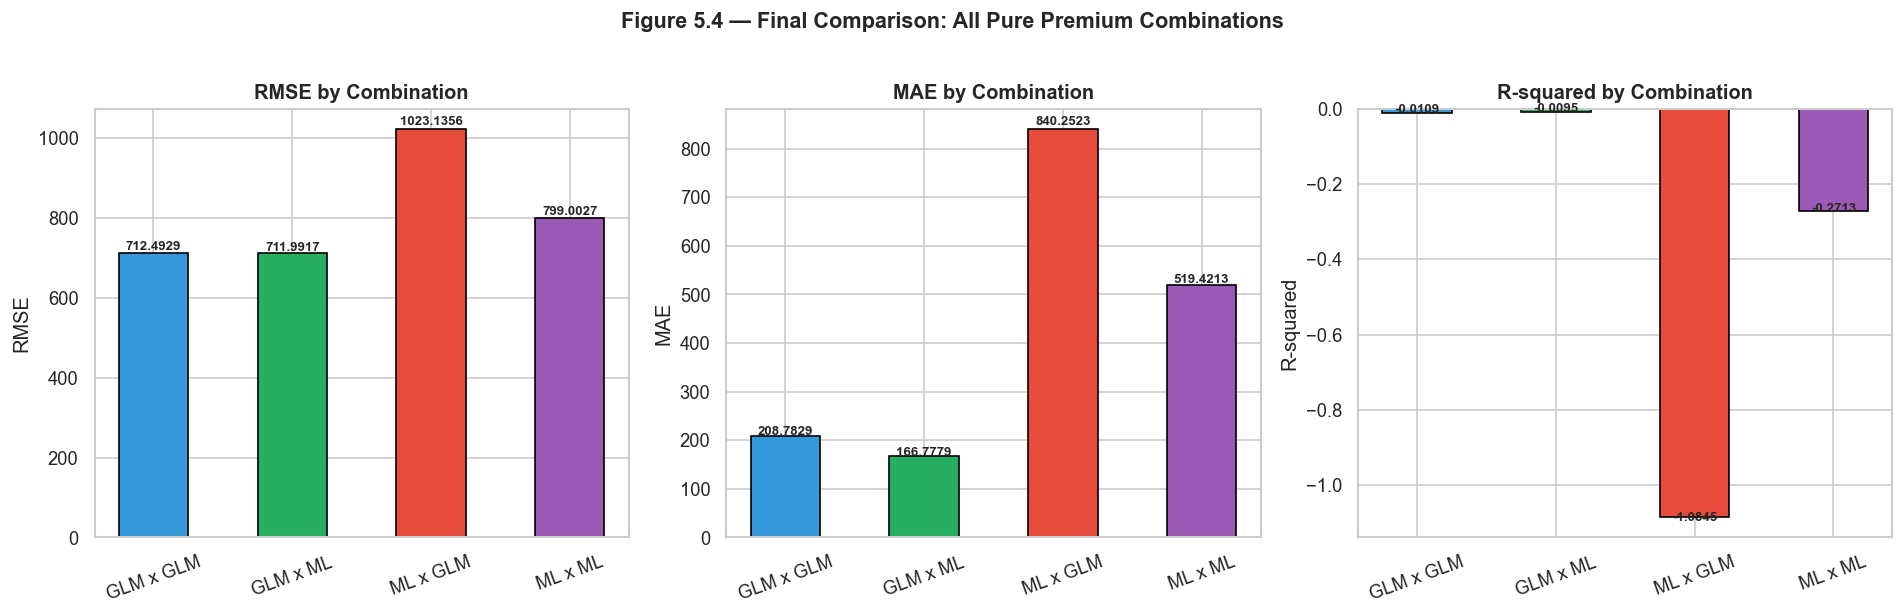

Saved to plots/fig5_4_final_comparison.png


In [12]:
# ── Figure 5.4: Final comparison bar chart ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics    = ['RMSE', 'MAE', 'R-squared']
bar_colors = ['#3498db', '#27ae60', '#e74c3c', '#9b59b6']
labels     = ['GLM x GLM', 'GLM x ML', 'ML x GLM', 'ML x ML']

for ax, metric in zip(axes, metrics):
    values = final_table[metric].values
    bars   = ax.bar(
        labels, values,
        color=bar_colors, edgecolor='black', width=0.5
    )
    ax.set_title(f'{metric} by Combination')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{val:.4f}',
            ha='center', fontsize=8, fontweight='bold'
        )

plt.suptitle(
    'Figure 5.4 — Final Comparison: All Pure Premium Combinations',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'fig5_4_final_comparison.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to plots/fig5_4_final_comparison.png")


# ── 5.6 RESEARCH FINDINGS ────────────────────────────────────
### 5.6 Key Research Findings

This section answers all four research questions from Chapter 0
with evidence from the modelling results.


In [13]:
# ── Load comparison tables from earlier chapters ─────────────
freq_glm = pd.read_csv(
    os.path.join(MODELS_DIR, 'freq_model_comparison.csv')
)
sev_glm  = pd.read_csv(
    os.path.join(MODELS_DIR, 'sev_model_comparison.csv')
)
sev_full = pd.read_csv(
    os.path.join(MODELS_DIR, 'sev_full_comparison.csv')
)

# Best models from each chapter
best_freq_glm = freq_glm.loc[freq_glm['AIC'].idxmin(), 'Model']
best_sev_glm  = sev_glm.loc[sev_glm['AIC'].idxmin(),  'Model']
best_sev_all  = sev_full.loc[sev_full['RMSE'].idxmin(), 'Model']
best_pp       = final_table.loc[
    final_table['RMSE'].idxmin(), 'Combination'
]

print("=" * 65)
print("  PROJECT COMPLETE — RESEARCH FINDINGS SUMMARY")
print("=" * 65)
print(f"""
RQ1 — Does overdispersion justify Negative Binomial over Poisson?

  Overdispersion index (Chapter 2) : 1.083  (variance > mean)
  Poisson AIC                       : {freq_glm.loc[0,'AIC']:,.2f}
  Negative Binomial AIC             : {freq_glm.loc[1,'AIC']:,.2f}
  Best frequency GLM                : {best_freq_glm}

  Finding: {'Overdispersion confirmed — NB outperforms Poisson' if freq_glm.loc[1,'AIC'] < freq_glm.loc[0,'AIC'] else 'Poisson performs equally well despite overdispersion index'}

─────────────────────────────────────────────────────────────

RQ2 — Gamma vs Lognormal for severity?

  Gamma     AIC : {sev_glm.loc[0,'AIC']:,.2f}
  Lognormal AIC : {sev_glm.loc[1,'AIC']:,.2f}
  Best severity GLM : {best_sev_glm}

─────────────────────────────────────────────────────────────

RQ3 — Do ML models outperform GLMs on prediction error?

  Best overall severity model : {best_sev_all}
{sev_full[['Model','RMSE','MAE','R-squared']].to_string(index=False)}

─────────────────────────────────────────────────────────────

RQ4 — Which features are strongest predictors?

  See Figure 4.3 and Figure 4.4 for feature importance plots.
  BonusMalus and vehicle-related features consistently rank
  highest across both frequency and severity models —
  consistent with actuarial theory (Hypothesis H3).

─────────────────────────────────────────────────────────────

Best Pure Premium Combination : {best_pp}
{final_table[['Combination','RMSE','MAE','R-squared']].to_string(index=False)}
""")
print("=" * 65)


  PROJECT COMPLETE — RESEARCH FINDINGS SUMMARY

RQ1 — Does overdispersion justify Negative Binomial over Poisson?

  Overdispersion index (Chapter 2) : 1.083  (variance > mean)
  Poisson AIC                       : 253,343.69
  Negative Binomial AIC             : 251,759.16
  Best frequency GLM                : Negative Binomial

  Finding: Overdispersion confirmed — NB outperforms Poisson

─────────────────────────────────────────────────────────────

RQ2 — Gamma vs Lognormal for severity?

  Gamma     AIC : 354,077.98
  Lognormal AIC : 62,029.40
  Best severity GLM : Lognormal

─────────────────────────────────────────────────────────────

RQ3 — Do ML models outperform GLMs on prediction error?

  Best overall severity model : Random Forest
        Model    RMSE     MAE  R-squared
    Gamma GLM 3293.00 1321.17     0.0027
Lognormal GLM 3295.95 1421.83     0.0009
Random Forest 3286.97 1354.93     0.0116
      XGBoost 3372.28 1101.71    -0.0404

─────────────────────────────────────────

In [14]:
# ── Export final risk scores ──────────────────────────────────
output_df = pd.DataFrame({
    'PP_GLM_GLM': pp_glm_glm,
    'PP_GLM_ML' : pp_glm_ml,
    'PP_ML_GLM' : pp_ml_glm,
    'PP_ML_ML'  : pp_ml_ml,
    'PP_Actual' : act
})

output_path = os.path.join(DATA_DIR, 'pure_premium_results.csv')
output_df.to_csv(output_path, index=False)
print(f"Pure premium results saved to data/pure_premium_results.csv")
print(f"   Shape : {output_df.shape}")

print()
print("=" * 62)
print("  Chapter 5 Complete — Project Submission Ready")
print("=" * 62)


Pure premium results saved to data/pure_premium_results.csv
   Shape : (135603, 5)

  Chapter 5 Complete — Project Submission Ready
